# EXPT NO: 1
## BUILDING AND TRAINING A SIMPLE ARTIFICIAL NEURAL NETWORK (ANN) FOR REGRESSION AND CLASSIFICATION

**Name:** Abhishek
**Roll No:** 24BAD002
**Date:** _______________

Dataset shape: (20640, 8)
Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Training samples: 16512
Testing samples: 4128


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.7424 - mae: 0.5875 - val_loss: 0.4647 - val_mae: 0.4669
Epoch 2/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3888 - mae: 0.4448 - val_loss: 0.3921 - val_mae: 0.4375
Epoch 3/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3593 - mae: 0.4263 - val_loss: 0.3709 - val_mae: 0.4246
Epoch 4/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.3422 - mae: 0.4144 - val_loss: 0.3573 - val_mae: 0.4139
Epoch 5/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3293 - mae: 0.4048 - val_loss: 0.3485 - val_mae: 0.4065
Epoch 6/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3185 - mae: 0.3972 - val_loss: 0.3425 - val_mae: 0.4024
Epoch 7/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3117 - mae: 0.3919 - val_loss: 0.3342 - val_mae: 0.3965
Epoch 8/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3055 - mae: 0.3869 - val_loss: 0.3299 - val_mae: 0.3950
Epoch 9/100
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/

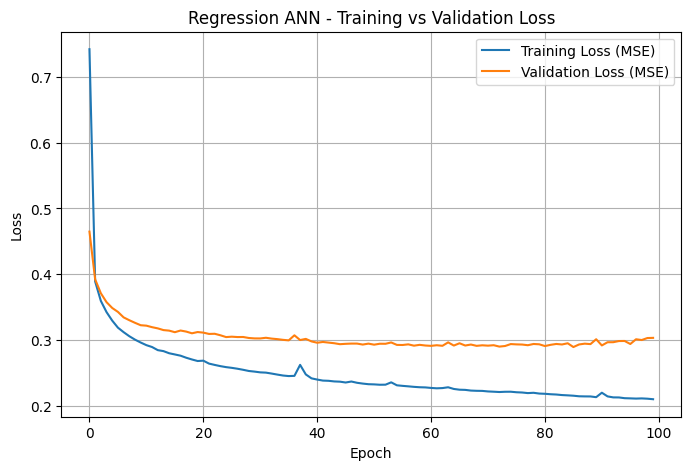

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Regression Evaluation Metrics
-----------------------------------
Mean Squared Error (MSE)  : 0.2905
Mean Absolute Error (MAE) : 0.3573
Root Mean Squared Error   : 0.5390


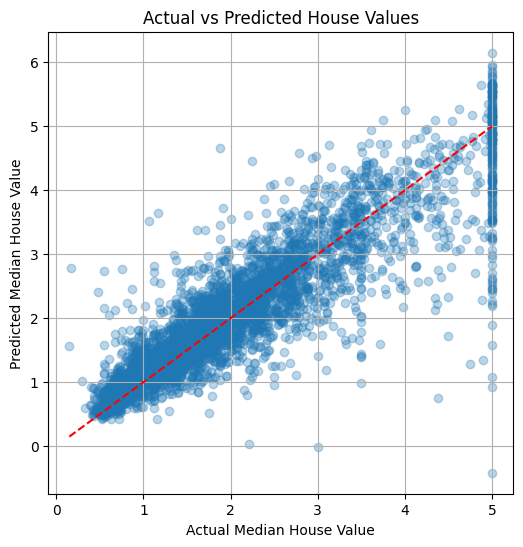

In [1]:
# EXPT NO: 1 - PART A: ANN FOR REGRESSION
# Name: Abhishek - Roll No: 24BAD002
# Step 1: Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

RANDOM_STATE = 2
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Step 2: Load California Housing dataset
housing = fetch_california_housing()
X = housing.data
y = housing.target

df = pd.DataFrame(X, columns=housing.feature_names)
df['MedHouseVal'] = y

print("Dataset shape:", X.shape)
print("Feature names:", housing.feature_names)
df.head()

# Step 3: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

# Step 4: Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Step 5: Build ANN model for regression
reg_model = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='linear')   # Linear output for regression
])

reg_model.summary()

# Step 6: Compile the model
reg_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

# Step 7: Train the model
reg_history = reg_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

# Visualize training vs validation loss
plt.figure(figsize=(8, 5))
plt.plot(reg_history.history['loss'], label='Training Loss (MSE)')
plt.plot(reg_history.history['val_loss'], label='Validation Loss (MSE)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Regression ANN - Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Step 8-9: Predict house prices and evaluate
y_pred = reg_model.predict(X_test_scaled).flatten()

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Regression Evaluation Metrics")
print("-" * 35)
print(f"Mean Squared Error (MSE)  : {mse:.4f}")
print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Root Mean Squared Error   : {rmse:.4f}")

# Bonus: Actual vs Predicted visualization
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Actual vs Predicted House Values')
plt.grid(True)
plt.show()

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']
Class distribution: [212 357]


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3709 - loss: 0.7668 - val_accuracy: 0.8462 - val_loss: 0.5555
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8764 - loss: 0.4846 - val_accuracy: 0.9451 - val_loss: 0.3370
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9258 - loss: 0.3231 - val_accuracy: 0.9451 - val_loss: 0.2154
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9478 - loss: 0.2295 - val_accuracy: 0.9560 - val_loss: 0.1531
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9588 - loss: 0.1768 - val_accuracy: 0.9670 - val_loss: 0.1180
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9698 - loss: 0.1437 - val_accuracy: 0.9670 - val_loss: 0.0957
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9698 - loss: 0.1214 - val_accuracy: 0.9780 - val_loss: 0.0814
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9725 - loss: 0.1055 - val_accuracy: 0.9780 - val_loss

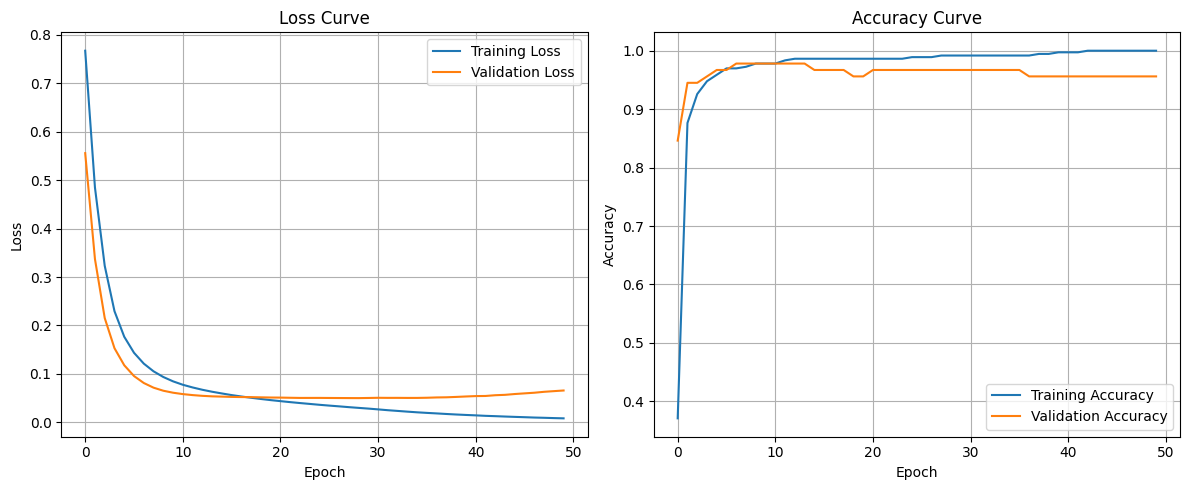

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Classification Evaluation Metrics
-----------------------------------
Accuracy  : 0.9912
Precision : 0.9863
Recall    : 1.0000
F1-score  : 0.9931

Classification Report:

              precision    recall  f1-score   support

   malignant       1.00      0.98      0.99        42
      benign       0.99      1.00      0.99        72

    accuracy                           0.99       114
   macro avg       0.99      0.99      0.99       114
weighted avg       0.99      0.99      0.99       114



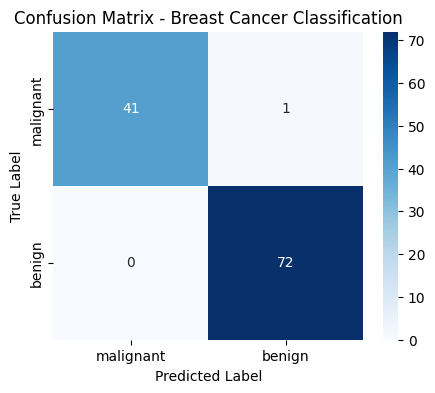

In [2]:
# EXPT NO: 1 - PART B: ANN FOR CLASSIFICATION
# Name: Abhishek - Roll No: 24BAD002
# Step 1: Import libraries

from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import seaborn as sns

# Step 2: Load Breast Cancer dataset
cancer = load_breast_cancer()
X_c = cancer.data
y_c = cancer.target   # 0 = malignant, 1 = benign

print("Dataset shape:", X_c.shape)
print("Classes:", cancer.target_names)
print("Class distribution:", np.bincount(y_c))

# Step 3: Split dataset
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_c, y_c, test_size=0.2, random_state=RANDOM_STATE, stratify=y_c
)

# Step 4: Standardize features
scaler_c = StandardScaler()
Xc_train_scaled = scaler_c.fit_transform(Xc_train)
Xc_test_scaled = scaler_c.transform(Xc_test)

# Step 5: Design ANN for classification
clf_model = keras.Sequential([
    layers.Input(shape=(Xc_train_scaled.shape[1],)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')   # Sigmoid for binary classification
])

clf_model.summary()

# Step 6: Compile model
clf_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Step 7: Train model
clf_history = clf_model.fit(
    Xc_train_scaled, yc_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

# Visualize training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(clf_history.history['loss'], label='Training Loss')
axes[0].plot(clf_history.history['val_loss'], label='Validation Loss')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(clf_history.history['accuracy'], label='Training Accuracy')
axes[1].plot(clf_history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Step 8-9: Predict labels and evaluate
yc_pred_prob = clf_model.predict(Xc_test_scaled).flatten()
yc_pred = (yc_pred_prob >= 0.5).astype(int)

accuracy = accuracy_score(yc_test, yc_pred)
precision = precision_score(yc_test, yc_pred)
recall = recall_score(yc_test, yc_pred)
f1 = f1_score(yc_test, yc_pred)

print("Classification Evaluation Metrics")
print("-" * 35)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print("\nClassification Report:\n")
print(classification_report(yc_test, yc_pred, target_names=cancer.target_names))

# Confusion Matrix
cm = confusion_matrix(yc_test, yc_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cancer.target_names, yticklabels=cancer.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Breast Cancer Classification')
plt.show()